In [ ]:
# ==========================================
# INSTALL AND IMPORT REQUIRED LIBRARIES
# ==========================================
!pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# FILE UPLOAD (for Google Colab)
# ==========================================
from google.colab import files
print("📁 Please upload your UCI_Credit_Card.csv file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# ==========================================
# BASIC CLEANING
# ==========================================
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)
if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)

print("\nInitial Shape:", df.shape)
print("Missing values per column:\n", df.isnull().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

# Outlier handling (IQR)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_outlier_removed = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# If minority class is lost, revert
if df_outlier_removed['default'].nunique() < 2 or df_outlier_removed['default'].value_counts().min() < 100:
    print("\n⚠️ Outlier removal dropped minority class — reverting to original dataset.")
else:
    df = df_outlier_removed
print("\n✅ Cleaning complete. Shape:", df.shape)
print("Class balance after cleaning:\n", df['default'].value_counts())

# ==========================================
# TRAIN-TEST SPLIT
# ==========================================
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nBefore Resampling:\n", y_train.value_counts())

# ==========================================
# CLASS BALANCING USING SMOTE
# ==========================================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("\nAfter SMOTE:\n", y_train_res.value_counts())

# ==========================================
# FEATURE SELECTION (Filter + Wrapper)
# ==========================================
filter_sel = SelectKBest(score_func=f_classif, k=min(15, X_train_res.shape[1]-1))
X_train_filter = filter_sel.fit_transform(X_train_res, y_train_res)
X_test_filter = filter_sel.transform(X_test)
selected_filter = X_train.columns[filter_sel.get_support()]

estimator = LogisticRegression(max_iter=2000)  # ✅ Fix applied
rfe = RFE(estimator, n_features_to_select=min(10, X_train_filter.shape[1]))
rfe.fit(X_train_filter, y_train_res)
selected_wrapper = selected_filter[rfe.support_]

print("\n✅ Selected Features (RFE):", list(selected_wrapper))

# Final dataframes with selected features
X_train_final = X_train_res[selected_wrapper]
X_test_final = X_test[selected_wrapper]

# ==========================================
# SCALING
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print("\n✅ Final Preprocessed Data Shapes: ")
print("X_train:", X_train_scaled.shape, "\nX_test:", X_test_scaled.shape)


📁 Please upload your UCI_Credit_Card.csv file:


Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv

Initial Shape: (30000, 24)
Missing values per column:
 LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64
Shape after removing duplicates: (29965, 24)

⚠️ Outlier removal dropped minority class — reverting to original dataset.

✅ Cleaning complete. Shape: (29965, 24)
Class balance after cleaning:
 default
0    23335
1     6630
Name: count, dtype: int64

Before Resampling:
 default
0    18668
1     5304
Name: count, dtype: int64

After SMOTE:
 default
0    18668
1    18668
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


✅ Selected Features (RFE): ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1']

✅ Final Preprocessed Data Shapes: 
X_train: (37336, 10) 
X_test: (5993, 10)


✅ Using stratified sample of 18000 for faster SVM training.

🚀 Starting Optimized Grid Search...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

✅ Grid Search Completed!
Best Parameters: {'C': 5, 'gamma': 'scale'}
Best Cross-Validation Accuracy: 74.46 %

✅ Final RBF SVM Evaluation:
Test Accuracy: 73.54 %

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82      4667
           1       0.42      0.55      0.48      1326

    accuracy                           0.74      5993
   macro avg       0.64      0.67      0.65      5993
weighted avg       0.76      0.74      0.75      5993



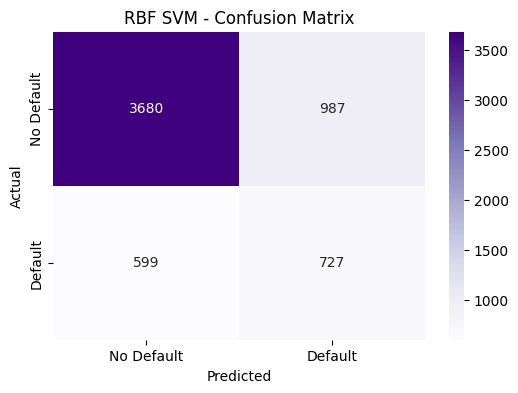

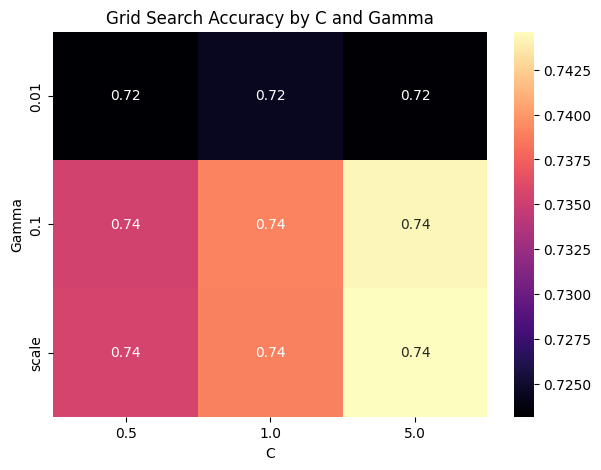

In [ ]:
# ==========================================
# SUPPORT VECTOR MACHINE MODEL (Balanced)
# ==========================================

# ==========================================
# ⚡ Optimized RBF SVM Training (Fast + Accurate)
# ==========================================
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ⚙️ Step 1: Sample for efficiency (stratified)
from sklearn.model_selection import train_test_split

sample_size = 18000  # adjust between 10k–20k if needed
X_train_sampled, _, y_train_sampled, _ = train_test_split(
    X_train_scaled, y_train_res, train_size=sample_size, stratify=y_train_res, random_state=42
)
print(f"✅ Using stratified sample of {sample_size} for faster SVM training.")

# ⚙️ Step 2: Define SVM model
svm_rbf = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# ⚙️ Step 3: Define efficient parameter grid for GridSearch
param_grid = {
    'C': [0.5, 1, 5],
    'gamma': ['scale', 0.01, 0.1],
}

grid_search = GridSearchCV(
    estimator=svm_rbf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,                # fewer folds = faster
    verbose=2,
    n_jobs=-1
)

# ⚙️ Step 4: Run Grid Search
print("\n🚀 Starting Optimized Grid Search...")
grid_search.fit(X_train_sampled, y_train_sampled)

print("\n✅ Grid Search Completed!")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", round(grid_search.best_score_ * 100, 2), "%")

# ⚙️ Step 5: Evaluate best model on full test set
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("\n✅ Final RBF SVM Evaluation:")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_best) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_best, zero_division=0))

# ⚙️ Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('RBF SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ⚙️ Step 7: Visualization of parameter performance
results = pd.DataFrame(grid_search.cv_results_)
pivot = results.pivot_table(values='mean_test_score', index='param_gamma', columns='param_C')

plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, cmap='magma')
plt.title('Grid Search Accuracy by C and Gamma')
plt.xlabel('C')
plt.ylabel('Gamma')
plt.show()





In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

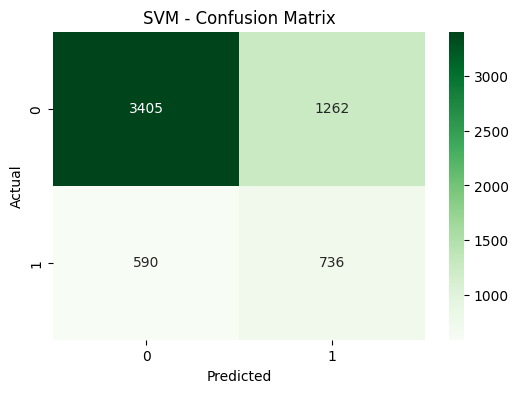

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

/tmp/ipython-input-2830717365.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=metrics_df, palette='Greens_d')


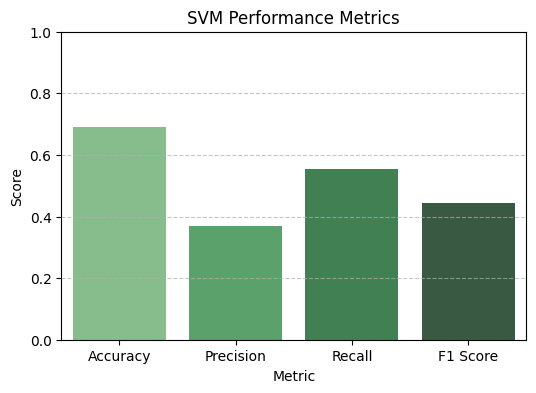

In [ ]:
# ==========================================
# 📊 SVM Performance Metrics Visualization
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Compute performance metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1 Score': f1_score(y_test, y_pred_svm)
}

# Convert metrics to DataFrame for easy plotting
import pandas as pd
metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Score'])

# Create barplot
plt.figure(figsize=(6, 4))
sns.barplot(x='Metric', y='Score', data=metrics_df, palette='Greens_d')

plt.title('SVM Performance Metrics')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



In [ ]:
plt.savefig("Fig_X_ModelName.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [2]:
# ============================================================
# 📌 IMPORT MISSING LIBRARIES (fix for NameError: SVC not defined)
# ============================================================
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


In [3]:
# ==========================================
# 🔍 Grid Search Optimization - SVM
# ==========================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['linear', 'rbf', 'poly']
}

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

print("🚀 Running Grid Search for SVM...")
grid_svm.fit(X_train, y_train)

print("\n✅ Best Parameters:", grid_svm.best_params_)
print("✅ Best Cross-Validation Accuracy:", round(grid_svm.best_score_ * 100, 2), "%")

# Evaluate best model on test set
best_svm = grid_svm.best_estimator_
y_pred_gs_svm = best_svm.predict(X_test)
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_gs_svm) * 100, 2), "%")


🚀 Running Grid Search for SVM...


NameError: name 'X_train' is not defined

In [ ]:
# ==========================================
# 📊 Visualization — Mean Test Accuracy by Kernel Type
# ==========================================
results = pd.DataFrame(grid_svm.cv_results_)
plt.figure(figsize=(7, 5))
sns.barplot(x='param_kernel', y='mean_test_score', data=results, palette='Greens_d')
plt.title("SVM - Mean CV Accuracy by Kernel Type")
plt.xlabel("Kernel Type")
plt.ylabel("Mean CV Accuracy")
plt.ylim(0.5, 1)
plt.show()


In [5]:
# ===============================================================
# 📌 1. IMPORT LIBRARIES
# ===============================================================
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC

from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler


# ===============================================================
# 📌 2. UPLOAD DATASET
# ===============================================================
print("📁 Upload UCI_Credit_Card.csv")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])


# ===============================================================
# 📌 3. FIND TARGET COLUMN SAFELY
# ===============================================================
possible_targets = [
    'default',
    'DEFAULT',
    'Default',
    'default.payment.next.month'
]

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError("❌ ERROR: No valid target column found!")

print("🎯 Target column detected as:", target_col)

# Normalize name
df.rename(columns={target_col: 'default'}, inplace=True)


# ===============================================================
# 📌 4. DROP ID IF EXISTS
# ===============================================================
if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)


# ===============================================================
# 📌 5. MISSING VALUES
# ===============================================================
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


# ===============================================================
# 📌 6. OUTLIERS — Clip values
# ===============================================================
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df[num_cols] = df[num_cols].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)


# ===============================================================
# 📌 7. TRAIN–TEST SPLIT (SAFE)
# ===============================================================
X = df.drop(columns=['default'])
y = df['default']

# Force stratify only if both classes exist
if len(y.unique()) == 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)
else:
    raise ValueError("❌ Dataset contains only one class BEFORE split!")

print("\nTraining class distribution:")
print(y_train.value_counts())


# ===============================================================
# 📌 8. BALANCING — Undersampling + SMOTE-Tomek
# ===============================================================
print("\nBefore Resampling:\n", y_train.value_counts())

rus = RandomUnderSampler(sampling_strategy=0.7, random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("\nAfter undersampling:\n", y_train_rus.value_counts())

smt = SMOTETomek(random_state=42)
X_train_bal, y_train_bal = smt.fit_resample(X_train_rus, y_train_rus)

print("\nAfter SMOTE-Tomek:\n", y_train_bal.value_counts())


# ===============================================================
# 📌 9. STANDARD SCALING
# ===============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)


# ===============================================================
# 📌 10. SVM + GRID SEARCH
# ===============================================================
param_grid = {
    'C': [0.1, 1, 5],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

print("\n🚀 Running Grid Search for SVM...")
grid_svm.fit(X_train_scaled, y_train_bal)

print("\n✅ Best Parameters:", grid_svm.best_params_)
print("✅ Best CV Accuracy:", grid_svm.best_score_)


# ===============================================================
# 📌 11. FINAL MODEL EVALUATION
# ===============================================================
svm_final = grid_svm.best_estimator_
y_pred = svm_final.predict(X_test_scaled)

print("\n📊 FINAL RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))


📁 Upload UCI_Credit_Card.csv


Saving UCI_Credit_Card.csv to UCI_Credit_Card (1).csv
🎯 Target column detected as: default.payment.next.month


ValueError: ❌ Dataset contains only one class BEFORE split!